In [54]:
from IPython.display import display
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)


path = "./nodes/table_total.csv"

df_table = pd.read_csv(path, encoding="utf-8-sig")
df_table[["통계표ID","통계표명","대상","구분","지역","연령대"]]

,통계표ID,통계표명,대상,구분,지역,연령대
0,DT_1SA100,"세종특별자치시 농가, 농가인구","농가, 농가인구",기준없음,세종,NaN
1,DT_1SA101,경지규모별 농가수,농가수,경지규모별,NaN,NaN
2,DT_1SA1011,논면적규모별 농가수,농가수,논면적 규모별,NaN,NaN
3,DT_1SA1011_01,"농가수, 논면적","농가수, 논면적",기준없음,NaN,NaN
4,DT_1SA1013,밭면적규모별 농가수,농가수,밭면적규모별,NaN,NaN
...,...,...,...,...,...,...
11811,DT_1A02038,시도별 · 이동유형별 귀산촌인,귀산촌인,"행정구역별, 이동유형별",NaN,NaN
11812,DT_1A02039,시도별 · 성별 · 연령별 귀산촌가구주,귀산촌가구주,"시도별, 성별, 연령별",NaN,NaN
11813,DT_1A02040,시도별(시군별) · 가구원수별 귀산촌가구,귀산촌가구,"행정구역별, 가구원수별",NaN,NaN
11814,DT_1A02041,시도별(시군별) · 가구 구성형태별 귀산촌가구,귀산촌가구,"행정구역별, 가구 구성형태별",NaN,NaN


In [55]:
'''
def remove_if_token_match(row):
    target_tokens = row["대상"].split()  # 공백 기준 토큰 분리
    filtered_tokens = [t for t in target_tokens if t != row["구분"]]  # 정확히 일치하는 토큰만 제거
    return " ".join(filtered_tokens)

df_table["대상"] = df_table.apply(remove_if_token_match, axis=1)
'''

'\ndef remove_if_token_match(row):\n    target_tokens = row["대상"].split()  # 공백 기준 토큰 분리\n    filtered_tokens = [t for t in target_tokens if t != row["구분"]]  # 정확히 일치하는 토큰만 제거\n    return " ".join(filtered_tokens)\n\ndf_table["대상"] = df_table.apply(remove_if_token_match, axis=1)\n'

In [57]:
import re
df_table["대상"] = df_table["대상"].apply(lambda x: re.sub(r'(.+?)\((.+?)\)', r'\1,\2', x))


# 각 셀의 값을 쉼표로 나누고, 요소별 공백 제거 + 특수기호 제거 후 다시 쉼표로 연결
df_table["대상"] = df_table["대상"].apply(
    lambda x: ",".join([
        re.sub(r'[^가-힣a-zA-Z0-9]', '', item.replace(" ", "")) 
        for item in str(x).split(",")
    ])
)

In [58]:
import re
df_table["구분"] = df_table["구분"].apply(lambda x: re.sub(r'(.+?)\((.+?)\)', r'\1,\2', x))


# 각 셀의 값을 쉼표로 나누고, 요소별 공백 제거 + 특수기호 제거 후 다시 쉼표로 연결
df_table["구분"] = df_table["구분"].apply(
    lambda x: ",".join([
        re.sub(r'[^가-힣a-zA-Z0-9]', '', item.replace(" ", "")) 
        for item in str(x).split(",")
    ])
)

In [59]:
df_table[["통계표ID","통계표명","대상","구분","지역","연령대"]]

,통계표ID,통계표명,대상,구분,지역,연령대
0,DT_1SA100,"세종특별자치시 농가, 농가인구","농가,농가인구",기준없음,세종,NaN
1,DT_1SA101,경지규모별 농가수,농가수,경지규모별,NaN,NaN
2,DT_1SA1011,논면적규모별 농가수,농가수,논면적규모별,NaN,NaN
3,DT_1SA1011_01,"농가수, 논면적","농가수,논면적",기준없음,NaN,NaN
4,DT_1SA1013,밭면적규모별 농가수,농가수,밭면적규모별,NaN,NaN
...,...,...,...,...,...,...
11811,DT_1A02038,시도별 · 이동유형별 귀산촌인,귀산촌인,"행정구역별,이동유형별",NaN,NaN
11812,DT_1A02039,시도별 · 성별 · 연령별 귀산촌가구주,귀산촌가구주,"시도별,성별,연령별",NaN,NaN
11813,DT_1A02040,시도별(시군별) · 가구원수별 귀산촌가구,귀산촌가구,"행정구역별,가구원수별",NaN,NaN
11814,DT_1A02041,시도별(시군별) · 가구 구성형태별 귀산촌가구,귀산촌가구,"행정구역별,가구구성형태별",NaN,NaN


### 대상/구분 요소 수정

In [60]:
def count_unique_elements(df, column, delimiter=","):
    """
    df: DataFrame
    column: 컬럼명 (문자열)
    delimiter: 각 셀 내 요소 구분자 (기본 쉼표)
    
    각 셀에 여러 개 값이 delimiter로 구분돼 있을 때,
    전체 고유 요소 개수를 반환합니다.
    """
    all_elements = (
        df[column]
        .dropna()
        .astype(str)
        .str.split(delimiter)
        .explode()
        .str.strip()
    )
    return all_elements, all_elements.nunique()

elements1, unique_count1 = count_unique_elements(df_table, "대상")
elements2, unique_count2 = count_unique_elements(df_table, "구분")

print(unique_count1)
print(unique_count2)


2586
1940


In [61]:
# 요소 길이별 빈도 계산
length_counts = elements1.astype(str).apply(len).value_counts().sort_index()

print(length_counts)

대상
1       74
2     5000
3     3549
4     4429
5     1637
6     1221
7      824
8      340
9      139
10     152
11      67
12      68
13      29
14      23
15       6
16       9
17       3
18       3
19       3
21       3
23       1
24       1
25       1
27       1
28       1
46       1
Name: count, dtype: int64


In [168]:
sum(length_counts)

17365

In [167]:
67+68+29+23+6+9+3+3
3+1+1+1+1+1


8

In [62]:
vc = elements1.value_counts()
print(vc[vc >= 10])

대상
인구       976
가구       836
농가       659
사업체수     580
취업자      466
        ... 
산란계       10
임금        10
유연근무제     10
돼지        10
사교육비      10
Name: count, Length: 261, dtype: int64


문제발생: 프롬프트에서 결과만을 출력하라고 했으나 문장 형태로 길게 응답한 경우가 존재함

In [39]:
# 길이 순(긴 것부터) 정렬
sorted_elements = sorted(elements1, key=len, reverse=False)

# 출력
for elem in sorted_elements:
    print("length",len(elem),":",elem)

length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 0 : 
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 방
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 물
length 1 : 성
length 1 : 성
length 1 : 시
length 1 : 군
length 1 : 구
length 1 : 읍
length 1 : 면
length 1 : 동
length 1 : 물
length 1 : 구
length 1 : 논
length 1 : 밭
length 1 : 밭
length 1 : 밤
length 1 : 소
length 1 : 밭
length 1 : 닭
length 1 : 닭
length 1 : 콩
length 1 : 콩
length 1 : 쌀
length 1 : 쌀
length 1 : 일
length 1 : 일
length 1 : 일
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 : 성
length 1 

## 유사도 노드
Fasttext로 단어 간 유사도 측정

https://fasttext.cc/docs/en/crawl-vectors.html

In [6]:
'''
!pip uninstall gensim
!pip uninstall fasttext
!pip install fasttext-wheel
'''

'\n!pip uninstall gensim\n!pip uninstall fasttext\n!pip install fasttext-wheel\n'

- 직접 다운받으면 C 드라이브 용량 40gb가 있어도 압축해제가 안됨
- 아래와 같이 다운로드하면 자동으로 압축해제되어 저장됨. 단 140분 걸림

In [8]:
import fasttext.util
fasttext.util.download_model('ko', if_exists='ignore')  # 한국어 모델

 (100.00%) [==================================================>]                                                 ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]>                                                  ]> 

'cc.ko.300.bin'

In [63]:
import numpy as np
import pandas as pd
import fasttext

ft = fasttext.load_model('./cc.ko.300.bin')

In [ ]:
# test

vec1 = ft.get_word_vector("사과")
vec2 = ft.get_word_vector("")
similarity = vec1 @ vec2 / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
similarity

-0.0029884367

In [85]:
# 빈도 10 이상 + 길이 1~10 단어 추출
vc = elements1.value_counts()
words = [word for word in vc.index if vc[word] >= 10 and 1 <= len(word) <= 10]

In [86]:
for word in words:
    vec = ft.get_word_vector(word)
    norm = np.linalg.norm(vec)
    if norm == 0:
        print(f"Zero norm vector found for word: {word}")

Zero norm vector found for word: 논벼


In [139]:
length_counts

대상
1       74
2     5000
3     3549
4     4429
5     1637
6     1221
7      824
8      340
9      139
10     152
Name: count, dtype: int64

In [160]:
length_counts

대상
2     5000
4     4429
3     3549
5     1637
6     1221
7      824
8      340
10     152
9      139
1       74
Name: count, dtype: int64

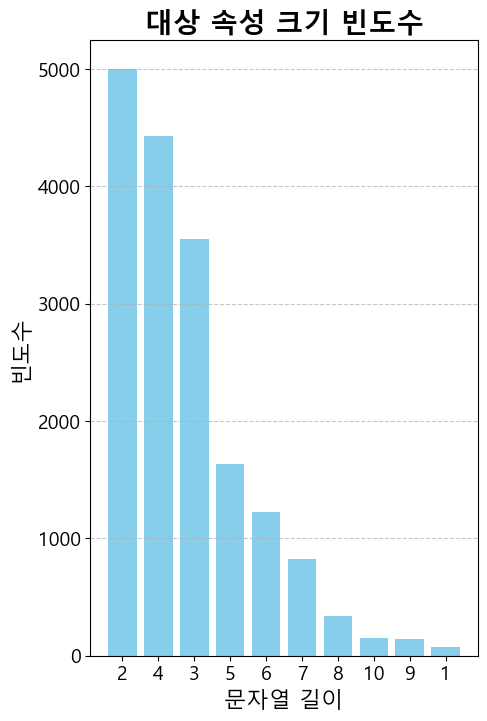

In [165]:
import matplotlib.pyplot as plt

# 1. df_table["대상"] 컬럼을 문자열로 변환 후 쉼표(,)로 분리
all_targets = df_table["대상"].astype(str).str.split(",").explode().str.strip()

# 2. null 제거 후 각 원소(문자열)의 길이 계산
lengths = all_targets.dropna().apply(len)
# 1) 길이별 빈도수 집계 후 상위 10개 추출 (값 기준 내림차순)
length_counts = lengths.value_counts().sort_values(ascending=False).head(10)

# 2) 값 기준 내림차순 정렬 (사실 위에서 이미 내림차순이라 생략 가능)
length_counts = length_counts.sort_values(ascending=False)

# 3) 인덱스와 값 그대로 유지된 상태에서 시각화
plt.figure(figsize=(5,8))
# x축은 인덱스(길이), y축은 값(빈도수)
plt.bar(length_counts.index.astype(str), length_counts.values, color='skyblue')

plt.xlabel('문자열 길이',fontsize=16)
plt.ylabel('빈도수',fontsize=16)
plt.title('대상 속성 크기 빈도수',fontsize=20,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [88]:
import pandas as pd
import numpy as np
import itertools


def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

results = []

# 3. 순열(permutations)으로 모든 (A,B), (B,A) 쌍 생성 (자기 자신 제외)
for w1, w2 in itertools.permutations(words, 2):
    vec1 = ft.get_word_vector(w1)
    vec2 = ft.get_word_vector(w2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        continue
    sim = cosine_similarity(vec1, vec2)
    if sim >= 0.3:
        results.append([w1, w2, sim])

df_sim = pd.DataFrame(results, columns=['source', 'target', 'sim_value'])

df_sim.to_csv('./nodes/node_similarity.csv', index=False, encoding='utf-8-sig')



## 구분 노드

In [101]:
# 길이 순(긴 것부터) 정렬
sorted_elements = sorted(elements2, key=len, reverse=True)

# 출력
for elem in sorted_elements:
    print("length",len(elem),":",elem)

length 131 : 거처의종류및점유형태별로분류한자료이므로다음과같은분류기준을확인할수있습니다성별남성과여성으로나누어분석했을가능성있음거처종류별주거형태를구분하여분석했을가능성있음점유형태별자가의여부나임대차계약등거주형태에따라분류하여분석했을가능성이있음따라서이통계표에서는성
length 68 : 거처의종류와점유형태를추가로분류하여시도별로정리한통계표이므로아래와같은분류기준들을추출할수있습니다성별거처의종류별점유형태별행정구역별
length 66 : 저축액및부채잔액을10분위로나눈분류기준인10분위별을확인할수있습니다따라서해당내용을토대로아래와같이정리할수있습니다소득10분위별
length 65 : 부양자와부양자의배우자에따른분류기준을찾을수없습니다따라서해당요청에대한답변은제공해드릴수없습니다다른도움이필요하시면말씀해주세요
length 65 : 주어진통계표에서명시적으로표현된분류기준은주된어업종류별입니다따라서이통계표는주된어업의종류를기준으로사업체의수를나타내고있습니다
length 60 : 주어진통계표에서는주된어업이라는분류기준을명시하고있습니다따라서이통계표를분석할때사용할수있는분류기준은주된어업별입니다
length 57 : 차별받은경험유무및차별받은주된이유를이민자로한정하여조사한통계표이므로분류기준이없습니다따라서기준없음을출력합니다
length 47 : 일반가구에대한명시적인분류기준이주어진문장에는없습니다따라서이경우에는기준없음을출력해야합니다
length 46 : 해수면어업에대한명시적인분류기준이주어진문장에는없습니다따라서이경우에는기준없음이출력됩니다
length 43 : 양식하는품목별로어가를분류한통계표를말합니다따라서이통계표에서의분류기준은품종별입니다
length 42 : 졸업예정자가한국에서의경험이후에도계속참여할의향이있는한국의문화사회경제정치등분야별
length 40 : 돌보는가족및가구원의비율을기준으로한분류기준이명시되어있지않으므로기준없음입니다
length 37 : 졸업예정자가한국에서의경험이후자신의진로나인생목표가어떻게변화했는지여부별
length 37 : 졸업예정자가한국에서의경험이후에도계속해서공부하고자하는의향이있는지여부별
length 35 : 졸

In [102]:
# 요소 길이별 빈도 계산
length_counts = elements2.astype(str).apply(len).value_counts().sort_index()

print(length_counts)

구분
1        15
2      2034
3      6096
4      1902
5      6061
6      2225
7      1256
8       481
9       218
10       84
11       42
12       23
13       21
14       17
15       15
16       14
17       10
18        2
19        2
20        4
22        3
23        1
26        3
27        1
28        1
29        7
30        2
31        5
34        1
35        2
37        2
40        1
42        1
43        1
46        1
47        1
57        1
60        1
65        2
66        1
68        1
131       1
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
    
# 윈도우 한글 기본 폰트 경로 예시 (환경에 따라 다를 수 있음)
font_path = "C:/Windows/Fonts/malgun.ttf"  

font_prop = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_prop

# 축에서 음수 부호가 깨지는 경우를 방지
plt.rcParams['axes.unicode_minus'] = False

구분
성별        1937
행정구역별     1678
시도별       1379
산업별       1329
연령별       1144
기준없음       900
인구별        369
교육정도별      345
직업별        317
종사자규모별     288
Name: count, dtype: int64


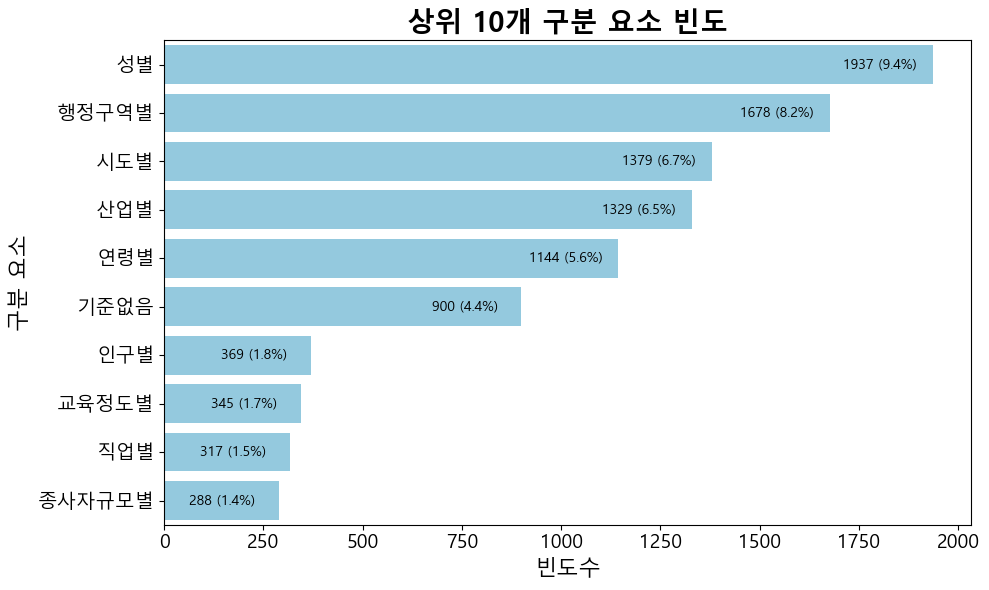

In [154]:
all_elements = df_table["구분"].astype(str).str.split(",").explode().str.strip()
counts = all_elements.dropna().value_counts()
print(counts.head(10))

import matplotlib.pyplot as plt
import seaborn as sns

top10 = counts.head(10)
total = counts.sum()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top10.values, y=top10.index, color='skyblue')

plt.title('상위 10개 구분 요소 빈도', fontsize=20, fontweight='bold')
plt.xlabel('빈도수', fontsize=16)
plt.ylabel('구분 요소', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 각 막대 오른쪽에 값과 비율 텍스트 추가
for i, (value, label) in enumerate(zip(top10.values, top10.index)):
    percent = value / total * 100
    ax.text(value - total*0.011, i, f'{value} ({percent:.1f}%)', va='center', color='black',fontsize=10)

plt.tight_layout()
plt.show()


In [115]:
from collections import Counter, defaultdict

words_list = all_elements.dropna().astype(str).tolist()
words_set = set(words_list)

substrings = []

# 2~4글자 부분문자열 추출 (고유 단어 기준)
for word in words_set:
    length = len(word)
    for n in range(2, 5):
        for i in range(length - n + 1):
            substr = word[i:i+n]
            substrings.append(substr)

counter = Counter(substrings)

# 빈도 높은 순서대로 정렬된 부분단어 리스트
most_common_substrings = [sub for sub, _ in counter.most_common()]

# 실제 단어 집합에 있는 부분단어 필터링
filtered_substrings = [w for w in most_common_substrings if w in words_set]

# 부분단어별 포함하는 원래 단어 목록 생성
substr_to_words = defaultdict(list)

for substr in filtered_substrings[:20]:  # 상위 20개만 예시로
    for w in words_list:
        if substr in w:
            substr_to_words[substr].append(w)

# 결과 출력
for substr, containing_words in substr_to_words.items():
    print(f"부분단어: {substr}")
    print(f"포함하는 단어들{(len(set(containing_words)))}: {list(set(containing_words))}\n")



부분단어: 규모별
포함하는 단어들108: ['동력선톤수규모별', '이통계표의분류기준은종사자규모별입니다', '퇴직연금제도도입사업장수를종사자규모별로나타낸통계표이므로', '수액채취규모별', '객석수규모별', '이동규모별', '보증금규모별', '인구규모별', '김양식규모별', '자본규모별', '자산규모별', '톤수규모별', '밭면적규모별', '수입액규모별', '재배면적규모별', '면적규모별', '직장규모별', '도소매업매출액규모별', '기업체규모별', '사글세규모별', '복숭아재배면적및수확면적규모별', '수리불안전답규모별', '사용방수및전세금규모별', '객실수규모별', '기업규모별', '연간판매액규모별', '사업체규모별', '지역규모별', '일자리규모별', '도시규모별', '매출액규모별', '밭경영규모별', '대전광역시구별산업별종사자규모별', '가구의규모별', '창고규모별', '매장면적규모별', '납입자본금규모별', '건물면적규모별', '서비스업매출액규모별', '사업장건물규모별', '사업자금규모별', '재배규모별', '산업종사자규모별', '시설수박수확면적규모별', '출자자규모별', '연면적규모별', '판매규모별', '굴양식규모별', '월세금규모별', '사글세계획규모별', '판매액규모별', '과수재배규모별', '판매금액규모별', '경지규모별', '시설면적규모별', '수원지면적규모별', '월세및보증금규모별', '논면적규모별', '수확규모별', '출자금규모별', '대구광역시구별산업별종사자규모별', '퇴직연금제도가입근로자수를종사자규모별로분류한통계표이므로', '자본잉여금규모별', '월세금및보증금규모별', '가구규모별', '산업건물연면적규모별', '어업규모별', '부산광역시구별산업별종사자규모별', '목초지규모별', '해당통계표에서명시적으로표현된분류기준은종사자규모별입니다', '생산규모별', '사업장건물면적규모별', '사육규모별', '인천광역시구별종사자규모별', '경지정리규모별', '전세규모별', '퇴직연금제도도입률을종사자규모별로나타낸통계표이므로', '자본금규모별', '해당통계표의

## 기존 df_table에 table_total의 정보 이식

In [173]:
df_merge = df_table[['통계표ID', '대상', '구분']]
df_merge['구분'] = df_merge['구분'].replace('기준없음', '')

df_merge

,통계표ID,대상,구분
0,DT_1SA100,"농가,농가인구",
1,DT_1SA101,농가수,경지규모별
2,DT_1SA1011,농가수,논면적규모별
3,DT_1SA1011_01,"농가수,논면적",
4,DT_1SA1013,농가수,밭면적규모별
...,...,...,...
11811,DT_1A02038,귀산촌인,"행정구역별,이동유형별"
11812,DT_1A02039,귀산촌가구주,"시도별,성별,연령별"
11813,DT_1A02040,귀산촌가구,"행정구역별,가구원수별"
11814,DT_1A02041,귀산촌가구,"행정구역별,가구구성형태별"


In [174]:
path_node = "./nodes/node_table.csv"

df_node = pd.read_csv(path_node, encoding="utf-8-sig")

df_node_updated = df_node.merge(df_merge, on='통계표ID', how='left')

df_node_updated.head()

,통계표ID,통계표명,승인번호,기관코드,주기,시작연도,마지막연도,지역,연령대,대상,구분
0,DT_1SA100,"세종특별자치시 농가, 농가인구",13002,101,부정기,2013,2013,세종,NaN,"농가,농가인구",
1,DT_1SA101,경지규모별 농가수,13002,101,부정기,2013,2013,NaN,NaN,농가수,경지규모별
2,DT_1SA1011,논면적규모별 농가수,13002,101,부정기,2013,2013,NaN,NaN,농가수,논면적규모별
3,DT_1SA1011_01,"농가수, 논면적",13002,101,부정기,2013,2013,NaN,NaN,"농가수,논면적",
4,DT_1SA1013,밭면적규모별 농가수,13002,101,부정기,2013,2013,NaN,NaN,농가수,밭면적규모별


In [175]:
df_node_updated.to_csv('./nodes/node_table_updated.csv', index=False)